In [2]:
!pip install matplotlib scipy requests -q

In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Use our S&P 500 universe from yesterday
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'AVGO', 'CRM', 'ORCL', 'AMD', 'INTC', 'QCOM', 'TXN',  # IT
    'JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'C', 'AXP', 'USB', 'PNC',              # Financials
    'JNJ', 'UNH', 'PFE', 'ABBV', 'MRK', 'TMO', 'ABT', 'DHR', 'BMY', 'AMGN',        # Healthcare
    'AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'TGT', 'LOW', 'GM', 'F',           # Cons Disc
    'PG', 'KO', 'PEP', 'WMT', 'COST', 'CL', 'KHC', 'GIS',                          # Cons Staples
    'NEE', 'DUK', 'SO', 'AEP', 'EXC', 'SRE', 'ED', 'XEL',                          # Utilities
    'LIN', 'APD', 'ECL', 'NEM', 'FCX', 'ALB', 'PPG', 'VMC',                        # Materials
    'RTX', 'HON', 'UPS', 'CAT', 'GE', 'MMM', 'DE', 'EMR',                          # Industrials
    'GOOGL', 'META', 'NFLX', 'DIS', 'CMCSA', 'T', 'VZ', 'TMUS',                    # Comm Services
    'AMT', 'PLD', 'CCI', 'EQIX', 'PSA', 'O', 'DLR', 'WELL',                        # Real Estate
    'XOM', 'CVX', 'COP', 'EOG', 'SLB', 'OXY'                                        # Energy
]

print(f"Universe: {len(tickers)} stocks")

Universe: 94 stocks


In [10]:
print("Fetching fundamental data...")
# Pull fundamental data for factor scoring
fundamentals = []
for ticker in tickers:
    try:
        info = yf.Ticker(ticker).info
        fundamentals.append({
            'ticker': ticker,
            'market_cap': info.get('marketCap', np.nan),
            'roe': info.get('returnOnEquity', np.nan),
            'debt_to_equity': info.get('debtToEquity', np.nan),
            'pe_ratio': info.get('trailingPE', np.nan),
            'pb_ratio': info.get('priceToBook', np.nan),
            'sector': info.get('sector', '')
        })
        print(f"  Fetched {ticker}")
    except:
        print(f"  Failed to fetch {ticker}")

df = pd.DataFrame(fundamentals)
print(f"\nFundamentals fetched: {len(df)} stocks")
print(df.head())

Fetching fundamental data...
  Fetched AAPL
  Fetched MSFT
  Fetched NVDA
  Fetched AVGO
  Fetched CRM
  Fetched ORCL
  Fetched AMD
  Fetched INTC
  Fetched QCOM
  Fetched TXN
  Fetched JPM
  Fetched BAC
  Fetched WFC
  Fetched GS
  Fetched MS
  Fetched BLK
  Fetched C
  Fetched AXP
  Fetched USB
  Fetched PNC
  Fetched JNJ
  Fetched UNH
  Fetched PFE
  Fetched ABBV
  Fetched MRK
  Fetched TMO
  Fetched ABT
  Fetched DHR
  Fetched BMY
  Fetched AMGN
  Fetched AMZN
  Fetched TSLA
  Fetched HD
  Fetched MCD
  Fetched NKE
  Fetched SBUX
  Fetched TGT
  Fetched LOW
  Fetched GM
  Fetched F
  Fetched PG
  Fetched KO
  Fetched PEP
  Fetched WMT
  Fetched COST
  Fetched CL
  Fetched KHC
  Fetched GIS
  Fetched NEE
  Fetched DUK
  Fetched SO
  Fetched AEP
  Fetched EXC
  Fetched SRE
  Fetched ED
  Fetched XEL
  Fetched LIN
  Fetched APD
  Fetched ECL
  Fetched NEM
  Fetched FCX
  Fetched ALB
  Fetched PPG
  Fetched VMC
  Fetched RTX
  Fetched HON
  Fetched UPS
  Fetched CAT
  Fetched GE
  Fetc

In [12]:
# Calculate factor scores
factors = df.copy()

# Remove rows with too many missing values
factors = factors.dropna(subset=['roe', 'pe_ratio', 'pb_ratio', 'market_cap'])
print(f"Stocks with complete data: {len(factors)}")

# FACTOR 1 — QUALITY SCORE
# High ROE = good quality
# Low debt/equity = good quality
# Fill missing debt_to_equity with median
factors['debt_to_equity'] = factors['debt_to_equity'].fillna(
    factors['debt_to_equity'].median()
)

# Winsorise at 5th and 95th percentile to handle outliers
def winsorise(series):
    low, high = series.quantile(0.05), series.quantile(0.95)
    return series.clip(low, high)

factors['roe_w'] = winsorise(factors['roe'])
factors['dte_w'] = winsorise(factors['debt_to_equity'])

# Z-score normalise
factors['roe_z'] = (factors['roe_w'] - factors['roe_w'].mean()) / factors['roe_w'].std()
factors['dte_z'] = (factors['dte_w'] - factors['dte_w'].mean()) / factors['dte_w'].std()

# Quality = high ROE, low debt
factors['quality_score'] = factors['roe_z'] - factors['dte_z']

# FACTOR 2 — VALUE SCORE  
# Low P/E and low P/B = cheap = good value
factors['pe_w'] = winsorise(factors['pe_ratio'])
factors['pb_w'] = winsorise(factors['pb_ratio'])

factors['pe_z'] = (factors['pe_w'] - factors['pe_w'].mean()) / factors['pe_w'].std()
factors['pb_z'] = (factors['pb_w'] - factors['pb_w'].mean()) / factors['pb_w'].std()

# Value = low P/E and low P/B (negative z-score = cheaper)
factors['value_score'] = -(factors['pe_z'] + factors['pb_z']) / 2

# COMPOSITE SCORE — equal weight quality and value for now
# We'll add momentum from price data next
factors['composite_score'] = (factors['quality_score'] + factors['value_score']) / 2

# Sort and display
factors_sorted = factors[['ticker', 'sector', 'quality_score', 
                           'value_score', 'composite_score']].sort_values(
    'composite_score', ascending=False
)

print("\nTop 15 stocks by composite score:")
print(factors_sorted.head(15).to_string())
print("\nBottom 10 stocks:")
print(factors_sorted.tail(10).to_string())

Stocks with complete data: 81

Top 15 stocks by composite score:
   ticker                  sector  quality_score  value_score  composite_score
23   ABBV              Healthcare       3.416824    -1.005175         1.205824
2    NVDA              Technology       3.866959    -1.616209         1.125375
0    AAPL              Technology       3.276463    -1.428395         0.924034
59    NEM         Basic Materials       0.839860     0.618397         0.729128
91    EOG                  Energy       0.512697     0.820422         0.666560
1    MSFT              Technology       1.176127     0.093549         0.634838
24    MRK              Healthcare       0.689100     0.548922         0.619011
72  GOOGL  Communication Services       1.350911    -0.179368         0.585772
40     PG      Consumer Defensive       0.731841     0.334005         0.532923
75    DIS  Communication Services       0.235904     0.817533         0.526719
74   NFLX  Communication Services       1.514483    -0.515722     

In [14]:
# Download 12 months of price data for momentum calculation
print("Downloading price data for momentum...")
prices = yf.download(
    factors['ticker'].tolist(), 
    start='2023-01-01', 
    end='2024-12-31',
    auto_adjust=True
)['Close']

# FACTOR 3 — MOMENTUM SCORE
# Standard momentum = 12-month return excluding last month (12-1 momentum)
# Avoids short-term reversal effect
monthly_prices = prices.resample('ME').last()

# 12-1 momentum: return from 12 months ago to 1 month ago
momentum_return = (monthly_prices.iloc[-2] / monthly_prices.iloc[-14] - 1)
momentum_df = momentum_return.reset_index()
momentum_df.columns = ['ticker', 'momentum_raw']

# Merge with factors
factors = factors.merge(momentum_df, on='ticker', how='left')

# Winsorise and z-score momentum
factors['momentum_w'] = winsorise(factors['momentum_raw'])
factors['momentum_score'] = (
    (factors['momentum_w'] - factors['momentum_w'].mean()) / 
    factors['momentum_w'].std()
)

# FINAL COMPOSITE SCORE — equal weight all three factors
factors['final_score'] = (
    factors['quality_score'] + 
    factors['value_score'] + 
    factors['momentum_score']
) / 3

# Select top and bottom quintile
factors_sorted = factors.sort_values('final_score', ascending=False)
top_quintile = factors_sorted.head(int(len(factors_sorted) * 0.2))
bottom_quintile = factors_sorted.tail(int(len(factors_sorted) * 0.2))

print(f"\nTotal stocks scored: {len(factors_sorted)}")
print(f"Top quintile (Long portfolio): {len(top_quintile)} stocks")
print(f"Bottom quintile (Short portfolio): {len(bottom_quintile)} stocks")
print("\nTop quintile:")
print(top_quintile[['ticker', 'sector', 'quality_score', 
                      'value_score', 'momentum_score', 
                      'final_score']].to_string())
print("\nBottom quintile:")
print(bottom_quintile[['ticker', 'sector', 'quality_score', 
                         'value_score', 'momentum_score', 
                         'final_score']].to_string())

[*********************100%***********************]  81 of 81 completed



Total stocks scored: 81
Top quintile (Long portfolio): 16 stocks
Bottom quintile (Short portfolio): 16 stocks

Top quintile:
   ticker                  sector  quality_score  value_score  momentum_score  final_score
2    NVDA              Technology       3.866959    -1.616209        1.786459     1.345736
62   NFLX  Communication Services       1.514483    -0.515722        1.786459     0.928407
61   META  Communication Services       0.948353     0.033832        1.616944     0.866376
19   ABBV              Healthcare       3.416824    -1.005175        0.022988     0.811546
11    WFC      Financial Services      -0.181492     0.916776        1.589347     0.774877
16    PNC      Financial Services      -0.178585     0.896636        1.262204     0.660085
9     JPM      Financial Services      -0.011779     0.781772        1.161359     0.643784
14    AXP      Financial Services      -0.279824     0.309518        1.782997     0.604230
56     GE             Industrials       0.824118    -0.

In [16]:
# Download longer price history for backtest
print("Downloading price history for backtest...")
all_tickers = factors['ticker'].tolist()
prices_bt = yf.download(
    all_tickers + ['SPY'],
    start='2020-01-01',
    end='2024-12-31',
    auto_adjust=True
)['Close']

returns_bt = prices_bt.pct_change().dropna()

# Equal weighted portfolios
long_tickers = top_quintile['ticker'].tolist()
short_tickers = bottom_quintile['ticker'].tolist()

# Filter to available tickers
long_valid = [t for t in long_tickers if t in returns_bt.columns]
short_valid = [t for t in short_tickers if t in returns_bt.columns]

# Portfolio returns
long_returns = returns_bt[long_valid].mean(axis=1)
short_returns = returns_bt[short_valid].mean(axis=1)
benchmark_returns = returns_bt['SPY']

# Long-short portfolio (long top quintile, short bottom quintile)
ls_returns = long_returns - short_returns

# Cumulative returns
long_cum = (1 + long_returns).cumprod()
short_cum = (1 + short_returns).cumprod()
ls_cum = (1 + ls_returns).cumprod()
bench_cum = (1 + benchmark_returns).cumprod()

# Performance metrics
def get_metrics(ret, label):
    ann_ret = ((1 + ret).prod() ** (252/len(ret)) - 1) * 100
    ann_vol = ret.std() * np.sqrt(252) * 100
    sharpe = (ann_ret/100 - 0.05) / (ann_vol/100)
    max_dd = ((1 + ret).cumprod() / (1 + ret).cumprod().cummax() - 1).min() * 100
    cum = ((1 + ret).cumprod().iloc[-1] - 1) * 100
    print(f"\n{label}:")
    print(f"  Annualised Return:    {ann_ret:.2f}%")
    print(f"  Annualised Volatility:{ann_vol:.2f}%")
    print(f"  Sharpe Ratio:         {sharpe:.2f}")
    print(f"  Max Drawdown:         {max_dd:.2f}%")
    print(f"  Cumulative Return:    {cum:.2f}%")
    return ann_ret, ann_vol, sharpe, max_dd, cum

print("=" * 55)
print("MULTI-FACTOR INDEX — BACKTEST RESULTS (2020-2024)")
print("=" * 55)
m_long = get_metrics(long_returns, "Long Portfolio (Top Quintile)")
m_short = get_metrics(short_returns, "Short Portfolio (Bottom Quintile)")
m_ls = get_metrics(ls_returns, "Long-Short Portfolio")
m_bench = get_metrics(benchmark_returns, "S&P 500 Benchmark (SPY)")

# Tracking error of long vs benchmark
active = long_returns - benchmark_returns
te = active.std() * np.sqrt(252) * 100
print(f"\nTracking Error (Long vs SPY): {te:.2f}%")
print(f"Active Return (Long vs SPY):  {m_long[0] - m_bench[0]:.2f}%")


[*********************100%***********************]  82 of 82 completed


MULTI-FACTOR INDEX — BACKTEST RESULTS (2020-2024)

Long Portfolio (Top Quintile):
  Annualised Return:    20.97%
  Annualised Volatility:24.88%
  Sharpe Ratio:         0.64
  Max Drawdown:         -37.14%
  Cumulative Return:    158.32%

Short Portfolio (Bottom Quintile):
  Annualised Return:    14.17%
  Annualised Volatility:21.72%
  Sharpe Ratio:         0.42
  Max Drawdown:         -34.58%
  Cumulative Return:    93.57%

Long-Short Portfolio:
  Annualised Return:    5.85%
  Annualised Volatility:12.97%
  Sharpe Ratio:         0.07
  Max Drawdown:         -36.28%
  Cumulative Return:    32.74%

S&P 500 Benchmark (SPY):
  Annualised Return:    14.37%
  Annualised Volatility:21.00%
  Sharpe Ratio:         0.45
  Max Drawdown:         -33.72%
  Cumulative Return:    95.30%

Tracking Error (Long vs SPY): 9.91%
Active Return (Long vs SPY):  6.60%


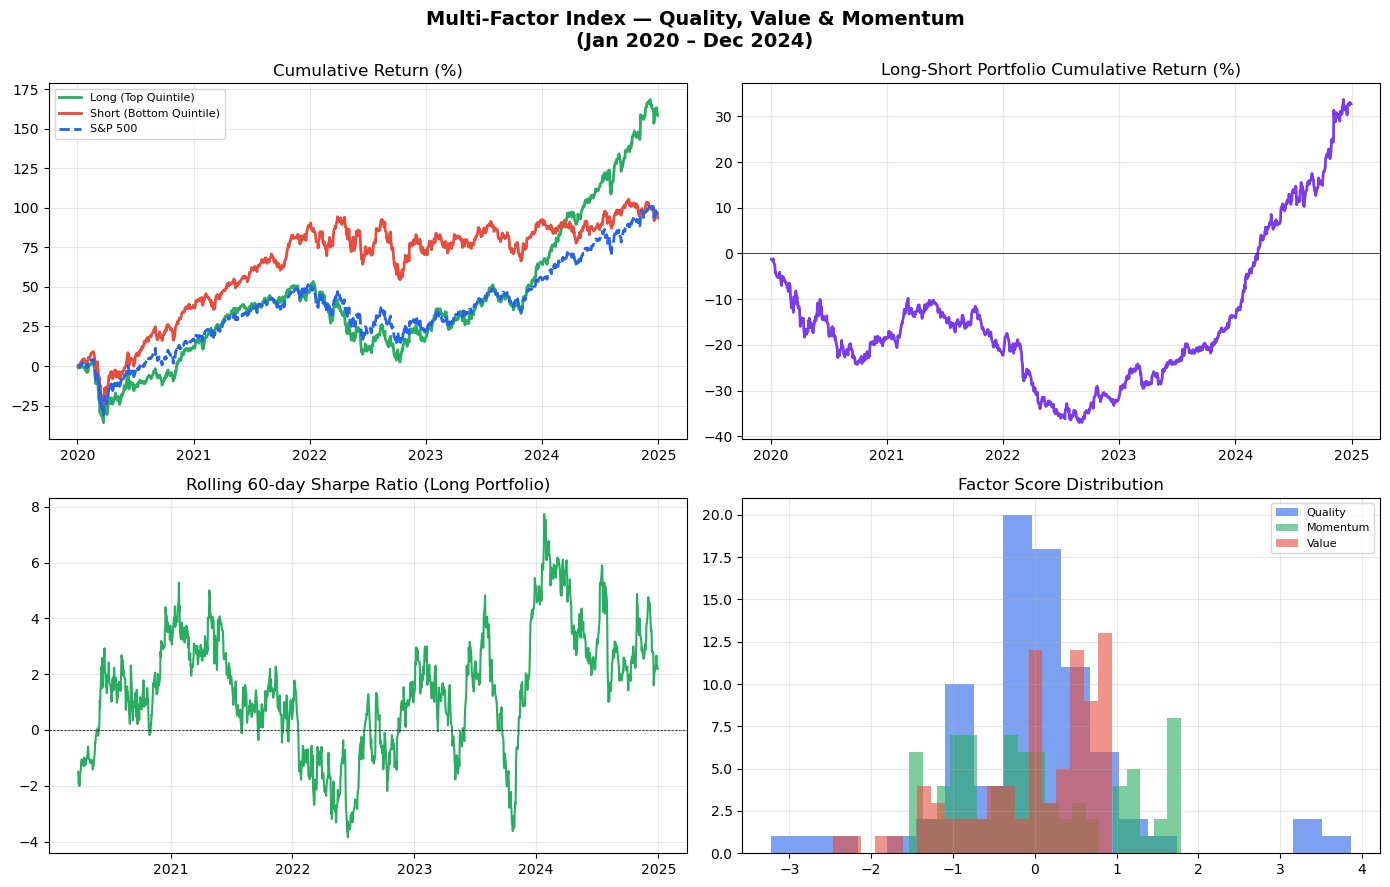

Chart saved.


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Multi-Factor Index — Quality, Value & Momentum\n(Jan 2020 – Dec 2024)', 
             fontsize=14, fontweight='bold')

# Plot 1 — Cumulative returns
ax1 = axes[0, 0]
ax1.plot(long_cum.index, (long_cum-1)*100, 
         label='Long (Top Quintile)', color='#27AE60', linewidth=2)
ax1.plot(short_cum.index, (short_cum-1)*100, 
         label='Short (Bottom Quintile)', color='#E74C3C', linewidth=2)
ax1.plot(bench_cum.index, (bench_cum-1)*100, 
         label='S&P 500', color='#2563EB', linewidth=2, linestyle='--')
ax1.set_title('Cumulative Return (%)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2 — Long-short portfolio
ax2 = axes[0, 1]
ax2.plot(ls_cum.index, (ls_cum-1)*100, 
         color='#7C3AED', linewidth=2)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('Long-Short Portfolio Cumulative Return (%)')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 3 — Rolling 60-day Sharpe of long portfolio
ax3 = axes[1, 0]
rolling_sharpe = (long_returns.rolling(60).mean() * 252 - 0.05) / \
                 (long_returns.rolling(60).std() * np.sqrt(252))
ax3.plot(rolling_sharpe.index, rolling_sharpe, 
         color='#27AE60', linewidth=1.5)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax3.set_title('Rolling 60-day Sharpe Ratio (Long Portfolio)')
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 4 — Factor score distribution
ax4 = axes[1, 1]
ax4.hist(factors['quality_score'], bins=20, alpha=0.6, 
         label='Quality', color='#2563EB')
ax4.hist(factors['momentum_score'], bins=20, alpha=0.6, 
         label='Momentum', color='#27AE60')
ax4.hist(factors['value_score'], bins=20, alpha=0.6, 
         label='Value', color='#E74C3C')
ax4.set_title('Factor Score Distribution')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('multifactor_index_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")


In [24]:
# Factor Correlation Matrix
factor_cols = ['quality_score', 'value_score', 'momentum_score']
corr_matrix = factors[factor_cols].corr()

print("Factor Correlation Matrix:")
print(corr_matrix.round(3))

Factor Correlation Matrix:
                quality_score  value_score  momentum_score
quality_score           1.000       -0.349           0.060
value_score            -0.349        1.000          -0.259
momentum_score          0.060       -0.259           1.000


In [26]:
# Sector Neutralisation
# Instead of ranking stocks globally, rank within each sector
# This removes sector bets and makes factor scores stock-specific

factors_neutral = factors.copy()

for factor in ['quality_score', 'value_score', 'momentum_score']:
    # Within each sector, z-score the factor
    factors_neutral[f'{factor}_neutral'] = factors_neutral.groupby('sector')[factor].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x - x.mean()
    )

# Composite score using neutralised factors
factors_neutral['final_score_neutral'] = (
    factors_neutral['quality_score_neutral'] +
    factors_neutral['value_score_neutral'] +
    factors_neutral['momentum_score_neutral']
) / 3

# Build neutralised portfolios
factors_neutral_sorted = factors_neutral.sort_values(
    'final_score_neutral', ascending=False
)

top_neutral = factors_neutral_sorted.head(int(len(factors_neutral_sorted) * 0.2))
bottom_neutral = factors_neutral_sorted.tail(int(len(factors_neutral_sorted) * 0.2))

# Compare sector weights — raw vs neutralised
def sector_weights(portfolio, label):
    weights = portfolio['sector'].value_counts(normalize=True) * 100
    return weights.rename(label)

raw_sectors = sector_weights(top_quintile, 'Raw')
neutral_sectors = sector_weights(top_neutral, 'Neutralised')
sector_comparison = pd.concat([raw_sectors, neutral_sectors], axis=1).fillna(0)

print("Sector weights — Raw vs Sector-Neutralised Long Portfolio:")
print(sector_comparison.round(1).to_string())

print(f"\nRaw top quintile tickers: {top_quintile['ticker'].tolist()}")
print(f"\nNeutralised top quintile tickers: {top_neutral['ticker'].tolist()}")

Sector weights — Raw vs Sector-Neutralised Long Portfolio:
                         Raw  Neutralised
sector                                   
Financial Services      43.8          6.2
Communication Services  18.8          6.2
Technology              12.5          6.2
Industrials             12.5         12.5
Healthcare               6.2          6.2
Consumer Defensive       6.2         12.5
Real Estate              0.0         18.8
Energy                   0.0         12.5
Basic Materials          0.0          6.2
Consumer Cyclical        0.0          6.2
Utilities                0.0          6.2

Raw top quintile tickers: ['NVDA', 'NFLX', 'META', 'ABBV', 'WFC', 'PNC', 'JPM', 'AXP', 'GE', 'BAC', 'AAPL', 'WMT', 'C', 'MMM', 'USB', 'T']

Neutralised top quintile tickers: ['EOG', 'NVDA', 'NEM', 'ABBV', 'XOM', 'PSA', 'WFC', 'WMT', 'DLR', 'AMZN', 'PG', 'WELL', 'AEP', 'META', 'GE', 'MMM']


In [28]:
# Backtest neutralised vs raw portfolio
long_neutral_tickers = top_neutral['ticker'].tolist()
long_neutral_valid = [t for t in long_neutral_tickers if t in returns_bt.columns]
long_neutral_returns = returns_bt[long_neutral_valid].mean(axis=1)
long_neutral_cum = (1 + long_neutral_returns).cumprod()

# Metrics comparison
print("=" * 55)
print("RAW vs SECTOR-NEUTRALISED COMPARISON")
print("=" * 55)
m_raw = get_metrics(long_returns, "Raw Factor Portfolio")
m_neutral = get_metrics(long_neutral_returns, "Sector-Neutralised Portfolio")
m_bench2 = get_metrics(benchmark_returns, "S&P 500 Benchmark")

# Tracking error comparison
te_raw = (long_returns - benchmark_returns).std() * np.sqrt(252) * 100
te_neutral = (long_neutral_returns - benchmark_returns).std() * np.sqrt(252) * 100

print(f"\nTracking Error:")
print(f"  Raw:         {te_raw:.2f}%")
print(f"  Neutralised: {te_neutral:.2f}%")

print(f"\nActive Return:")
print(f"  Raw:         {m_raw[0] - m_bench2[0]:.2f}%")
print(f"  Neutralised: {m_neutral[0] - m_bench2[0]:.2f}%")

# Sector concentration (HHI - Herfindahl index)
def hhi(portfolio):
    weights = portfolio['sector'].value_counts(normalize=True)
    return (weights ** 2).sum()

print(f"\nSector Concentration (HHI — lower is better):")
print(f"  Raw:         {hhi(top_quintile):.3f}")
print(f"  Neutralised: {hhi(top_neutral):.3f}")

RAW vs SECTOR-NEUTRALISED COMPARISON

Raw Factor Portfolio:
  Annualised Return:    20.97%
  Annualised Volatility:24.88%
  Sharpe Ratio:         0.64
  Max Drawdown:         -37.14%
  Cumulative Return:    158.32%

Sector-Neutralised Portfolio:
  Annualised Return:    21.22%
  Annualised Volatility:20.32%
  Sharpe Ratio:         0.80
  Max Drawdown:         -31.53%
  Cumulative Return:    160.99%

S&P 500 Benchmark:
  Annualised Return:    14.37%
  Annualised Volatility:21.00%
  Sharpe Ratio:         0.45
  Max Drawdown:         -33.72%
  Cumulative Return:    95.30%

Tracking Error:
  Raw:         9.91%
  Neutralised: 7.44%

Active Return:
  Raw:         6.60%
  Neutralised: 6.85%

Sector Concentration (HHI — lower is better):
  Raw:         0.266
  Neutralised: 0.109


In [30]:
ir_raw = (m_raw[0] - m_bench2[0]) / te_raw
ir_neutral = (m_neutral[0] - m_bench2[0]) / te_neutral

print(f"Information Ratio:")
print(f"  Raw:         {ir_raw:.2f}")
print(f"  Neutralised: {ir_neutral:.2f}")

Information Ratio:
  Raw:         0.67
  Neutralised: 0.92


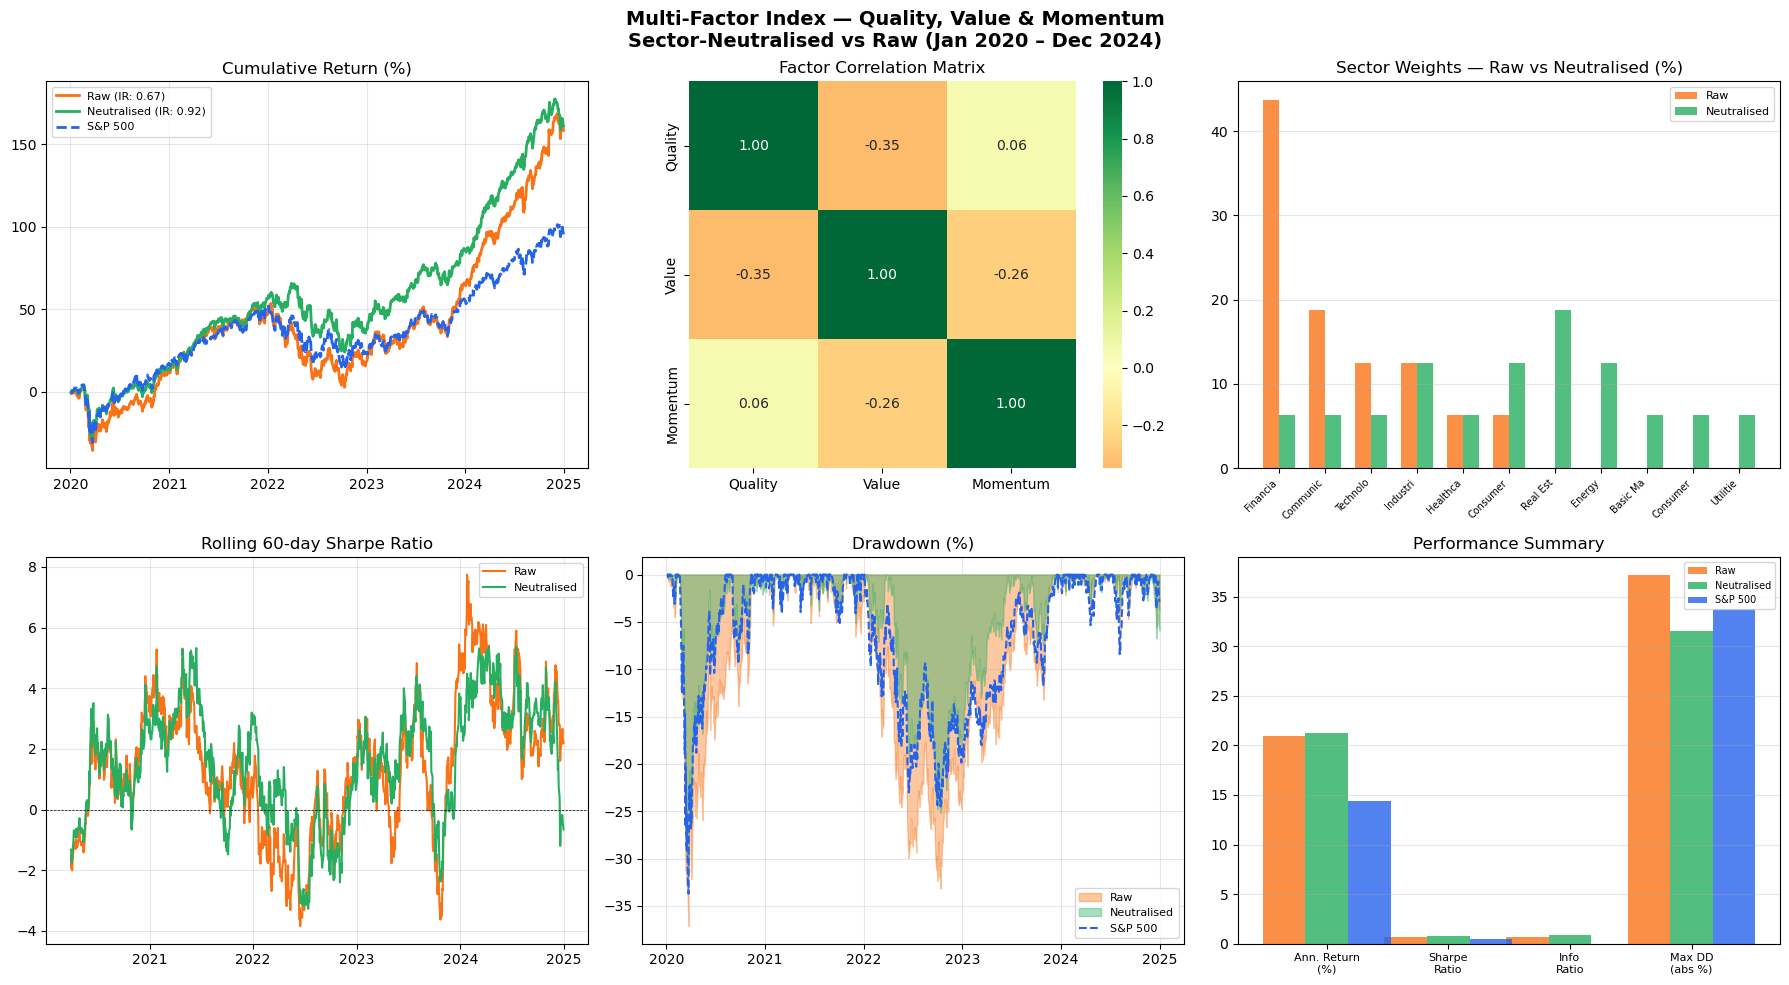

Chart saved.


In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Factor Index — Quality, Value & Momentum\nSector-Neutralised vs Raw (Jan 2020 – Dec 2024)', 
             fontsize=14, fontweight='bold')

# Plot 1 — Cumulative returns comparison
ax1 = axes[0, 0]
ax1.plot(long_cum.index, (long_cum-1)*100,
         label=f'Raw (IR: {ir_raw:.2f})', color='#F97316', linewidth=2)
ax1.plot(long_neutral_cum.index, (long_neutral_cum-1)*100,
         label=f'Neutralised (IR: {ir_neutral:.2f})', color='#27AE60', linewidth=2)
ax1.plot(bench_cum.index, (bench_cum-1)*100,
         label='S&P 500', color='#2563EB', linewidth=2, linestyle='--')
ax1.set_title('Cumulative Return (%)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2 — Factor correlation heatmap
ax2 = axes[0, 1]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax2, square=True,
            xticklabels=['Quality', 'Value', 'Momentum'],
            yticklabels=['Quality', 'Value', 'Momentum'])
ax2.set_title('Factor Correlation Matrix')

# Plot 3 — Sector weights comparison
ax3 = axes[0, 2]
x = np.arange(len(sector_comparison))
width = 0.35
bars1 = ax3.bar(x - width/2, sector_comparison['Raw'], 
                width, label='Raw', color='#F97316', alpha=0.8)
bars2 = ax3.bar(x + width/2, sector_comparison['Neutralised'], 
                width, label='Neutralised', color='#27AE60', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels([s[:8] for s in sector_comparison.index], 
                     rotation=45, ha='right', fontsize=7)
ax3.set_title('Sector Weights — Raw vs Neutralised (%)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4 — Rolling Sharpe comparison
ax4 = axes[1, 0]
roll_sharpe_raw = (long_returns.rolling(60).mean() * 252 - 0.05) / \
                  (long_returns.rolling(60).std() * np.sqrt(252))
roll_sharpe_neutral = (long_neutral_returns.rolling(60).mean() * 252 - 0.05) / \
                      (long_neutral_returns.rolling(60).std() * np.sqrt(252))
ax4.plot(roll_sharpe_raw.index, roll_sharpe_raw,
         label='Raw', color='#F97316', linewidth=1.5)
ax4.plot(roll_sharpe_neutral.index, roll_sharpe_neutral,
         label='Neutralised', color='#27AE60', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax4.set_title('Rolling 60-day Sharpe Ratio')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 5 — Drawdown comparison
ax5 = axes[1, 1]
dd_raw = ((1+long_returns).cumprod() /
          (1+long_returns).cumprod().cummax() - 1) * 100
dd_neutral = ((1+long_neutral_returns).cumprod() /
              (1+long_neutral_returns).cumprod().cummax() - 1) * 100
dd_bench = ((1+benchmark_returns).cumprod() /
            (1+benchmark_returns).cumprod().cummax() - 1) * 100
ax5.fill_between(dd_raw.index, dd_raw, 0,
                  alpha=0.4, color='#F97316', label='Raw')
ax5.fill_between(dd_neutral.index, dd_neutral, 0,
                  alpha=0.4, color='#27AE60', label='Neutralised')
ax5.plot(dd_bench.index, dd_bench,
         color='#2563EB', linewidth=1.5, linestyle='--', label='S&P 500')
ax5.set_title('Drawdown (%)')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 6 — Summary metrics bar chart
ax6 = axes[1, 2]
metrics_labels = ['Ann. Return\n(%)', 'Sharpe\nRatio', 'Info\nRatio', 
                   'Max DD\n(abs %)']
raw_vals = [m_raw[0], m_raw[2], ir_raw, abs(m_raw[3])]
neutral_vals = [m_neutral[0], m_neutral[2], ir_neutral, abs(m_neutral[3])]
bench_vals = [m_bench2[0], m_bench2[2], 0, abs(m_bench2[3])]

x2 = np.arange(len(metrics_labels))
ax6.bar(x2 - width, raw_vals, width, label='Raw', color='#F97316', alpha=0.8)
ax6.bar(x2, neutral_vals, width, label='Neutralised', color='#27AE60', alpha=0.8)
ax6.bar(x2 + width, bench_vals, width, label='S&P 500', color='#2563EB', alpha=0.8)
ax6.set_xticks(x2)
ax6.set_xticklabels(metrics_labels, fontsize=8)
ax6.set_title('Performance Summary')
ax6.legend(fontsize=7)
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('multifactor_results_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")